## This is the code for generating Feature Heatmap plot.

By default, if you play this file directly, it will generate the Feature Heatmap plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists -> Compute the pairwise weighted Kendall tau matrix -> Turn the Matrix into the corresponding heatmap

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The Feature Heatmap Plot 

You don't need to change anything else if you only want to produce the Heatmap plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [12]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

# Influence Ranking Read-In Area

Again, change here for your desired influence lists.

In [13]:
IF_1 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_00.csv")
IF_2 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_10.csv")
IF_3 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_14.csv")
IF_4 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_18.csv")
IF_5 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_22.csv")
IF_6 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_26.csv")
IF_7 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_30.csv")
IF_8 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_34.csv")
IF_9 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_38.csv")
IF_10 = pd.read_csv("NumberOfFeatures/IF_Feature_Column_10_42.csv")

TC_1 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_00.csv")
TC_2 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_10.csv")
TC_3 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_14.csv")
TC_4 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_18.csv")
TC_5 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_22.csv")
TC_6 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_26.csv")
TC_7 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_30.csv")
TC_8 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_34.csv")
TC_9 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_38.csv")
TC_10 = pd.read_csv("NumberOfFeatures/TC_Feature_Column_10_42.csv")

In [14]:
sorted_IF_lists = [IF_1, IF_2,IF_3,IF_4,IF_5,IF_6,IF_7,IF_8,IF_9,IF_10]
sorted_TC_lists = [TC_1, TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,TC_9,TC_10]
Train_Size = [10,20,24,28,32,36,40,44,48,52]

1. Here we initial the weighted kendall tau matrix.

In [15]:
num_lists = len(sorted_IF_lists)

In [16]:
tau_matrix_TC = np.full((num_lists, num_lists), np.nan)
tau_matrix_IF = np.full((num_lists, num_lists), np.nan)
print(tau_matrix_IF)

[[nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]]


2. Here we compute the pairwise weighted kendall tau value for all the Influence Function's ranked influence lists.

In [17]:
for i in range(num_lists):
    tau_matrix_IF[i, i] = 1.0
    for j in range(i + 1, num_lists):
        df1 = sorted_IF_lists[i]
        df2 = sorted_IF_lists[j]
        max_abs1 = df1['Score'].abs().max()
        df1['Score'] = df1['Score'] / max_abs1    
        max_abs2 = df2['Score'].abs().max()
        df2['Score'] = df2['Score'] / max_abs2
        merged = pd.merge(df1, df2, on='Train_ID', how='inner')
        wt, _ = weightedtau(merged["Score_x"], merged["Score_y"],
                        weigher = lambda x: (np.abs(merged["Score_x"][x]) + np.abs(merged["Score_y"][x]))/2, rank = None)
        #wt, _ = kendalltau(merged["Score_x"], merged["Score_y"])
        tau_matrix_IF[i, j] = wt
        tau_matrix_IF[j, i] = wt

print(tau_matrix_IF)

[[1.         0.81082197 0.7805646  0.76100458 0.72754805 0.71973298
  0.71560611 0.70296601 0.68206173 0.65432459]
 [0.81082197 1.         0.88656886 0.81758762 0.79729318 0.76821204
  0.76024081 0.74158342 0.73504277 0.71741597]
 [0.7805646  0.88656886 1.         0.86272058 0.84506982 0.8182992
  0.80322184 0.79011885 0.77613271 0.76080745]
 [0.76100458 0.81758762 0.86272058 1.         0.90533908 0.86972802
  0.84705997 0.82505612 0.79983654 0.79191179]
 [0.72754805 0.79729318 0.84506982 0.90533908 1.         0.90132957
  0.87393501 0.84718589 0.82799712 0.81717926]
 [0.71973298 0.76821204 0.8182992  0.86972802 0.90132957 1.
  0.90818276 0.86828254 0.85088715 0.83334916]
 [0.71560611 0.76024081 0.80322184 0.84705997 0.87393501 0.90818276
  1.         0.90062544 0.87103883 0.85444973]
 [0.70296601 0.74158342 0.79011885 0.82505612 0.84718589 0.86828254
  0.90062544 1.         0.89888212 0.87648531]
 [0.68206173 0.73504277 0.77613271 0.79983654 0.82799712 0.85088715
  0.87103883 0.898882

3. Here we compute the pairwise weighted kendall tau value for all the TracIn's ranked influence lists.

In [18]:
for i in range(num_lists):
    tau_matrix_TC[i, i] = 1.0
    for j in range(i + 1, num_lists):
        df1 = sorted_TC_lists[i]
        df2 = sorted_TC_lists[j]
        max_abs1 = df1['Score'].abs().max()
        df1['Score'] = df1['Score'] / max_abs1    
        max_abs2 = df2['Score'].abs().max()
        df2['Score'] = df2['Score'] / max_abs2
        merged = pd.merge(df1, df2, on='Train_ID', how='inner')
        wt, _ = weightedtau(merged["Score_x"], merged["Score_y"],
                         weigher = lambda x: (np.abs(merged["Score_x"][x]) + np.abs(merged["Score_y"][x]))/2, rank = None)
        #wt, _ = kendalltau(merged["Score_x"], merged["Score_y"])
        tau_matrix_TC[i, j] = wt
        tau_matrix_TC[j, i] = wt

print(tau_matrix_TC)

[[1.         0.94487603 0.93835224 0.93604944 0.93034786 0.92806442
  0.92414386 0.92105136 0.91767726 0.91052906]
 [0.94487603 1.         0.96594103 0.95112484 0.94045592 0.93705586
  0.93225971 0.92915763 0.92718978 0.91867463]
 [0.93835224 0.96594103 1.         0.96271205 0.9521786  0.94758917
  0.93936556 0.93677061 0.93401999 0.9265169 ]
 [0.93604944 0.95112484 0.96271205 1.         0.97005972 0.96221043
  0.95104879 0.94747787 0.94434667 0.93745015]
 [0.93034786 0.94045592 0.9521786  0.97005972 1.         0.97252759
  0.95924259 0.9546804  0.94986209 0.94242012]
 [0.92806442 0.93705586 0.94758917 0.96221043 0.97252759 1.
  0.97087065 0.96225971 0.95694782 0.94892113]
 [0.92414386 0.93225971 0.93936556 0.95104879 0.95924259 0.97087065
  1.         0.97085146 0.95964177 0.95190217]
 [0.92105136 0.92915763 0.93677061 0.94747787 0.9546804  0.96225971
  0.97085146 1.         0.97033232 0.96078452]
 [0.91767726 0.92718978 0.93401999 0.94434667 0.94986209 0.95694782
  0.95964177 0.97033

4. Now we turn each weighted tau matrix into a triangular heatmap. This is to remove the duplicate half.

In [19]:
labels = [f"{size:}" for idx, size in enumerate(Train_Size)]
df_tau_IF = pd.DataFrame(tau_matrix_IF, index=labels, columns=labels)
df_tau_TC = pd.DataFrame(tau_matrix_TC, index=labels, columns=labels)

In [20]:
mask_lower = np.triu(np.ones_like(tau_matrix_IF, dtype=bool), k=1)
triangular_IF = tau_matrix_IF.copy()
triangular_IF[mask_lower] = np.nan
triangular_TC = tau_matrix_TC.copy()
triangular_TC[mask_lower] = np.nan

print(mask_lower)

[[False  True  True  True  True  True  True  True  True  True]
 [False False  True  True  True  True  True  True  True  True]
 [False False False  True  True  True  True  True  True  True]
 [False False False False  True  True  True  True  True  True]
 [False False False False False  True  True  True  True  True]
 [False False False False False False  True  True  True  True]
 [False False False False False False False  True  True  True]
 [False False False False False False False False  True  True]
 [False False False False False False False False False  True]
 [False False False False False False False False False False]]


IF

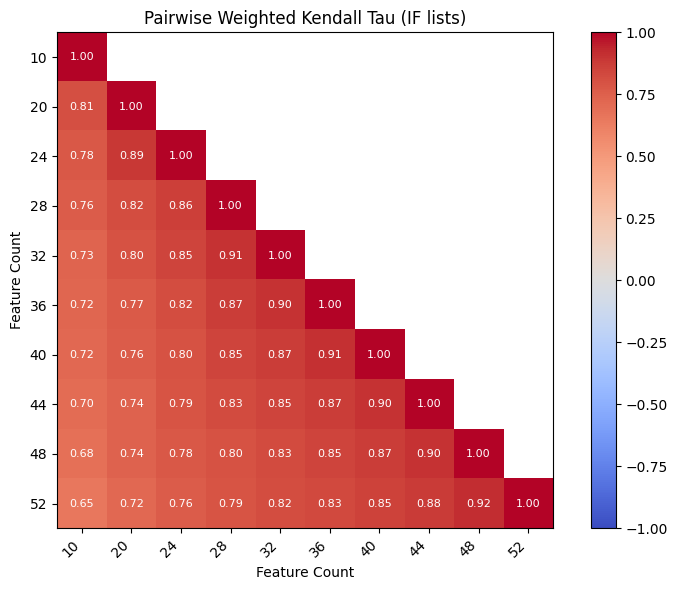

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_IF, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Pairwise Weighted Kendall Tau (IF lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels)

rows, cols = np.where(~np.isnan(triangular_IF))
for i, j in zip(rows, cols):
    val = triangular_IF[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)
plt.xlabel("Feature Count")
plt.ylabel("Feature Count")
plt.tight_layout()
plt.show()

TC

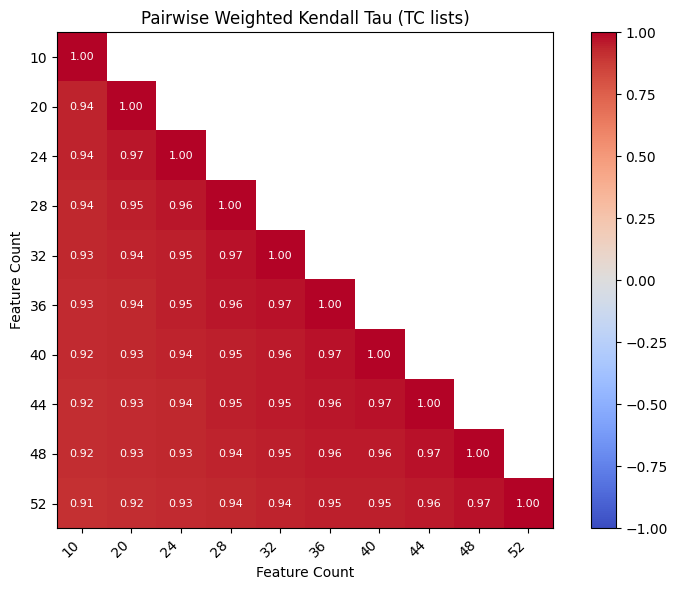

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_TC, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Pairwise Weighted Kendall Tau (TC lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels)

rows, cols = np.where(~np.isnan(triangular_TC))
for i, j in zip(rows, cols):
    val = triangular_TC[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)
plt.xlabel("Feature Count")
plt.ylabel("Feature Count")
plt.tight_layout()
plt.show()